In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("virginia_housing_cleaned.csv")

In [4]:
df.shape
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9406 entries, 0 to 9405
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status            9406 non-null   object 
 1   text              9406 non-null   object 
 2   style             9406 non-null   object 
 3   zip_code          9406 non-null   int64  
 4   days_on_mls       9406 non-null   float64
 5   list_price        9406 non-null   float64
 6   list_date         9406 non-null   object 
 7   new_construction  9406 non-null   bool   
 8   county            9406 non-null   object 
 9   stories           9406 non-null   float64
 10  home_age          9406 non-null   float64
 11  total_baths       9406 non-null   float64
 12  desc_words        9406 non-null   int64  
 13  listing_month     9406 non-null   int64  
 14  log_price         9406 non-null   float64
 15  log_sqft          9406 non-null   float64
dtypes: bool(1), float64(7), int64(3), object(5

status              0
text                0
style               0
zip_code            0
days_on_mls         0
list_price          0
list_date           0
new_construction    0
county              0
stories             0
home_age            0
total_baths         0
desc_words          0
listing_month       0
log_price           0
log_sqft            0
dtype: int64

In [5]:
print(df.shape)

(9406, 16)


In [6]:
df.head()

,status,text,style,zip_code,days_on_mls,list_price,list_date,new_construction,county,stories,home_age,total_baths,desc_words,listing_month,log_price,log_sqft
0,FOR_SALE,List price is starting bid only. Home will be ...,SINGLE_FAMILY,24592,5.0,250000.0,2026-04-20 19:45:25,False,Halifax,2.0,27.0,4.5,125,4,12.429216,8.272315
1,FOR_SALE,HOME CAN NOT BE ENTERED. Sold strictly as is. ...,SINGLE_FAMILY,24112,10.0,30200.0,2026-04-16 13:31:14,False,Henry,2.0,272.0,1.0,44,4,10.315597,7.433667
2,FOR_SALE,Charming 1 Level Rambler Situated on a Generou...,SINGLE_FAMILY,23005,26.0,299900.0,2026-03-30 20:05:49,False,Hanover,1.0,61.0,2.0,126,3,12.611204,7.539559
3,FOR_SALE,Auction Property: List price may not reflect f...,SINGLE_FAMILY,24133,12.0,109000.0,2026-04-13 16:19:45,False,Patrick,2.0,58.0,2.0,126,4,11.599103,7.404888
4,FOR_SALE,"Property is owned by the US Dept of HUD, home ...",SINGLE_FAMILY,24018,10.0,277000.0,2026-04-16 10:27:40,False,Roanoke,1.0,30.0,2.0,70,4,12.531773,7.396335


In [7]:
df[["text","desc_words"]].sample(5, random_state=42)

,text,desc_words
7677,P R I M E- Must see! This 6.1 acre cleared lot...,141
2175,Charming ranch home nestled on a no-through st...,120
6651,Just Completed. New one level living in Lockri...,22
3037,Charming rancher for sale in Richmond! This ho...,106
8011,Gently laying 5.32 ACRE cul-de-sac lot located...,55


In [8]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words="english")
X_words = cv.fit_transform(df["text"])

word_counts = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "count": X_words.toarray().sum(axis=0)
})

word_counts = word_counts.sort_values("count", ascending=False)

word_counts.head(60)

,word,count
9464,home,19856
10900,living,13789
14668,room,13015
15779,space,10209
10743,level,8816
12319,offers,8774
10394,kitchen,8468
3815,bath,8073
12072,new,7756
12921,perfect,6268


In [9]:
cv2 = CountVectorizer(stop_words="english", ngram_range=(2,2), min_df=20)

X2 = cv2.fit_transform(df["text"])

phrases = pd.DataFrame({
    "phrase": cv2.get_feature_names_out(),
    "count": X2.toarray().sum(axis=0)
}).sort_values("count", ascending=False)

phrases.head(50)

,phrase,count
3657,main level,3208
4612,primary suite,2990
3496,living space,2197
2747,home offers,2193
6261,walk closet,2127
1992,family room,2054
668,bedroom bath,2023
3492,living room,1915
917,car garage,1874
5683,stainless steel,1846


In [10]:
import pandas as pd
pd.set_option("display.max_rows", 250)

In [11]:
word_counts.head(250)

,word,count
9464,home,19856
10900,living,13789
14668,room,13015
15779,space,10209
10743,level,8816
12319,offers,8774
10394,kitchen,8468
3815,bath,8073
12072,new,7756
12921,perfect,6268


In [12]:
phrases.head(250)

,phrase,count
3657,main level,3208
4612,primary suite,2990
3496,living space,2197
2747,home offers,2193
6261,walk closet,2127
1992,family room,2054
668,bedroom bath,2023
3492,living room,1915
917,car garage,1874
5683,stainless steel,1846


In [13]:
# make lowercase text once
df["text_clean"] = df["text"].str.lower()

# --------------------------
# premium finishes score
# --------------------------
premium_words = [
    "stainless steel",
    "granite countertops",
    "quartz countertops",
    "hardwood floors",
    "vaulted ceilings",
    "gourmet kitchen",
    "chef kitchen"
]

# --------------------------
# layout score
# --------------------------
layout_words = [
    "open concept",
    "primary suite",
    "main level",
    "home office",
    "laundry room"
]

# --------------------------
# condition score
# --------------------------
condition_words = [
    "brand new",
    "new construction",
    "fully renovated",
    "updated kitchen",
    "fresh paint"
]

# --------------------------
# outdoor score
# --------------------------
outdoor_words = [
    "screened porch",
    "covered porch",
    "rear deck",
    "walking trails"
]

# --------------------------
# location score
# --------------------------
location_words = [
    "mountain views",
    "prime location",
    "conveniently located",
    "corner lot",
    "cul sac"
]

# function to count phrase matches
def phrase_count(text, phrase_list):
    return sum(phrase in text for phrase in phrase_list)

df["premium_score"]   = df["text_clean"].apply(lambda x: phrase_count(x, premium_words))
df["layout_score"]    = df["text_clean"].apply(lambda x: phrase_count(x, layout_words))
df["condition_score"] = df["text_clean"].apply(lambda x: phrase_count(x, condition_words))
df["outdoor_score"]   = df["text_clean"].apply(lambda x: phrase_count(x, outdoor_words))
df["location_score"]  = df["text_clean"].apply(lambda x: phrase_count(x, location_words))

In [14]:
features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories",
    "premium_score",
    "layout_score",
    "condition_score",
    "outdoor_score",
    "location_score"
]

X = df[features]
y = df["log_price"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R²:", round(r2,3))
print("RMSE:", round(rmse,3))
print("MAE:", round(mae,3))

R²: 0.333
RMSE: 0.764
MAE: 0.486


In [19]:
coef = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coef.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
1,total_baths,0.370458
0,log_sqft,0.254340
7,condition_score,0.123211
6,layout_score,0.120954
5,premium_score,0.118978
8,outdoor_score,0.093223
2,home_age,0.002229
3,days_on_mls,-0.000990
9,location_score,-0.033362
4,stories,-0.042420


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# -------------------------
# features
# -------------------------
num_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories",
    "premium_score",
    "layout_score",
    "condition_score",
    "outdoor_score",
    "location_score"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

X = df[num_features + cat_features]
y = df["log_price"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# preprocess
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="passthrough"
)

# pipeline
model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

# fit
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", round(r2,3))
print("RMSE:", round(rmse,3))

R2: 0.578
RMSE: 0.608


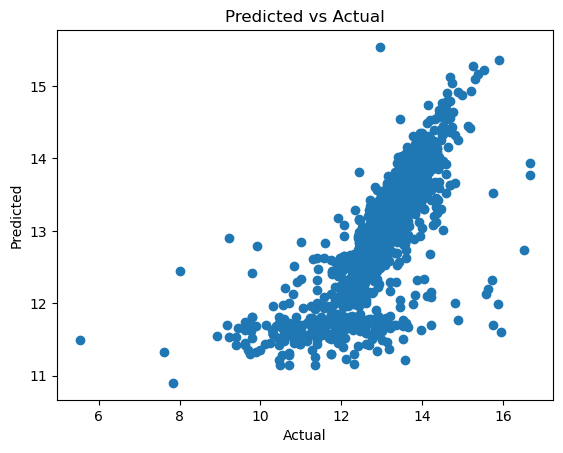

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

In [22]:
# Same model, but remove the text scores
num_features_no_text = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

X = df[num_features_no_text + cat_features]
y = df["log_price"]

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="passthrough"
)

model_no_text = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

model_no_text.fit(X_train, y_train)

y_pred_no_text = model_no_text.predict(X_test)

print("No Text Model")
print("R2:", round(r2_score(y_test, y_pred_no_text), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_no_text)), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred_no_text), 3))

No Text Model
R2: 0.578
RMSE: 0.608
MAE: 0.336


In [24]:
num_features_with_text = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories",
    "premium_score",
    "layout_score",
    "condition_score",
    "outdoor_score",
    "location_score"
]

X = df[num_features_with_text + cat_features]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model_with_text = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

model_with_text.fit(X_train, y_train)

y_pred_with_text = model_with_text.predict(X_test)

print("With Text Score Model")
print("R2:", round(r2_score(y_test, y_pred_with_text), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_with_text)), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred_with_text), 3))

With Text Score Model
R2: 0.578
RMSE: 0.608
MAE: 0.336


In [25]:
results = pd.DataFrame({
    "Model": ["No Text", "With Text Scores"],
    "R2": [
        r2_score(y_test, y_pred_no_text),
        r2_score(y_test, y_pred_with_text)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_no_text)),
        np.sqrt(mean_squared_error(y_test, y_pred_with_text))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_no_text),
        mean_absolute_error(y_test, y_pred_with_text)
    ]
})

results

,Model,R2,RMSE,MAE
0,No Text,0.577689,0.607992,0.336350
1,With Text Scores,0.578273,0.607571,0.335531


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

num_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

text_feature = "text"

X = df[num_features + cat_features + [text_feature]]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [27]:
tfidf_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("text", TfidfVectorizer(
            stop_words="english",
            max_features=100,
            ngram_range=(1,2)
        ), text_feature)
    ],
    remainder="passthrough"
)

tfidf_model = Pipeline([
    ("prep", tfidf_preprocessor),
    ("reg", LinearRegression())
])

tfidf_model.fit(X_train, y_train)

y_pred_tfidf = tfidf_model.predict(X_test)

print("TF-IDF Model")
print("R2:", round(r2_score(y_test, y_pred_tfidf), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_tfidf)), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred_tfidf), 3))

TF-IDF Model
R2: 0.611
RMSE: 0.584
MAE: 0.336


In [28]:
results = pd.DataFrame({
    "Model": ["No Text", "Text Scores", "TF-IDF"],
    "R2": [
        r2_score(y_test, y_pred_no_text),
        r2_score(y_test, y_pred_with_text),
        r2_score(y_test, y_pred_tfidf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_no_text)),
        np.sqrt(mean_squared_error(y_test, y_pred_with_text)),
        np.sqrt(mean_squared_error(y_test, y_pred_tfidf))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_no_text),
        mean_absolute_error(y_test, y_pred_with_text),
        mean_absolute_error(y_test, y_pred_tfidf)
    ]
})

results

,Model,R2,RMSE,MAE
0,No Text,0.577689,0.607992,0.336350
1,Text Scores,0.578273,0.607571,0.335531
2,TF-IDF,0.610555,0.583855,0.336188


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

num_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

text_feature = "text"

X = df[num_features + cat_features + [text_feature]]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [30]:
results = []

for max_features in [2500,2800,3000]:
    for alpha in [2,3,4,5]:

        preprocessor = ColumnTransformer(
            transformers=[
                ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
                ("text", TfidfVectorizer(
                    stop_words="english",
                    max_features=max_features,
                    ngram_range=(1, 2)
                ), text_feature)
            ],
            remainder="passthrough"
        )

        model = Pipeline([
            ("prep", preprocessor),
            ("ridge", Ridge(alpha=alpha))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        results.append({
            "max_features": max_features,
            "alpha": alpha,
            "R2": r2_score(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAE": mean_absolute_error(y_test, y_pred)
        })

ridge_results = pd.DataFrame(results)

ridge_results.sort_values("R2", ascending=False).head(10)

,max_features,alpha,R2,RMSE,MAE
4,2800,2,0.735545,0.481125,0.286475
0,2500,2,0.735332,0.481318,0.286999
8,3000,2,0.734200,0.482346,0.286232
5,2800,3,0.729841,0.486286,0.284338
1,2500,3,0.729720,0.486394,0.284631
9,3000,3,0.728651,0.487355,0.284152
2,2500,4,0.723925,0.491581,0.284342
6,2800,4,0.723883,0.491618,0.284057
10,3000,4,0.722818,0.492566,0.283866
3,2500,5,0.718431,0.496449,0.284611


In [31]:
from sklearn.metrics import r2_score

# predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# scores
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R2:", round(train_r2,3))
print("Test R2 :", round(test_r2,3))
print("Gap     :", round(train_r2 - test_r2,3))

Train R2: 0.821
Test R2 : 0.717
Gap     : 0.104


In [32]:
# get TF-IDF feature names
feature_names = model.named_steps["prep"].named_transformers_["text"].get_feature_names_out()

# get Ridge coefficients
coefs = model.named_steps["ridge"].coef_

# IMPORTANT: your pipeline order is cat, text, then numeric
cat_names = model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features)

start = len(cat_names)
end = start + len(feature_names)

text_coefs = pd.DataFrame({
    "word": feature_names,
    "coef": coefs[start:end]
})

# words/phrases associated with higher predicted price
text_coefs.sort_values("coef", ascending=False).head(20)

,word,coef
717,development,1.015058
952,farm,0.915705
101,acres,0.907889
2933,waterfront,0.889123
884,estate,0.817091
2763,tract,0.764397
2956,wildlife,0.716484
1095,frontage,0.680766
526,commercial,0.666923
136,agricultural,0.628014


In [33]:
text_coefs.sort_values("coef", ascending=True).head(20)

,word,coef
208,auction,-1.287205
1630,lot,-0.816903
531,community,-0.689281
2514,sold,-0.649017
394,buy,-0.635048
2088,priced,-0.611973
379,building,-0.609652
2884,virtual,-0.554040
133,affordable,-0.528857
2141,property sold,-0.504514


In [34]:
model.named_steps["ridge"].coef_

array([-0.28925906,  0.34306359,  0.7420749 , ..., -0.00130582,
        0.00077422,  0.00594625])

In [35]:
df["luxury_flag"] = df["text_clean"].str.contains("luxury").astype(int)

import statsmodels.api as sm

X = sm.add_constant(df[["luxury_flag", "log_sqft", "total_baths"]])
y = df["log_price"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     1565.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:36:47   Log-Likelihood:                -10346.
No. Observations:                9406   AIC:                         2.070e+04
Df Residuals:                    9402   BIC:                         2.073e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           9.8945      0.176     56.321      

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X = df["text"]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_text_only = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=2000)),
    ("reg", LinearRegression())
])

model_text_only.fit(X_train, y_train)
y_pred = model_text_only.predict(X_test)

print("Text Only Model")
print("R2:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))

Text Only Model
R2: 0.573
RMSE: 0.612


In [37]:
import statsmodels.api as sm

# Select features (adjust if needed)
X = df[[
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories",
    "premium_score",
    "layout_score",
    "condition_score",
    "outdoor_score",
    "location_score"
]]

X = sm.add_constant(X)
y = df["log_price"]

model_ols = sm.OLS(y, X).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     572.1
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:36:49   Log-Likelihood:                -10013.
No. Observations:                9406   AIC:                         2.005e+04
Df Residuals:                    9395   BIC:                         2.013e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.7568      0.172     

In [38]:
# Baseline model (NO TEXT)
X_base = df[[
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]]
X_base = sm.add_constant(X_base)

model_base = sm.OLS(y, X_base).fit()

# Full model (WITH TEXT)
X_full = df[[
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories",
    "premium_score",
    "layout_score",
    "condition_score",
    "outdoor_score",
    "location_score"
]]
X_full = sm.add_constant(X_full)

model_full = sm.OLS(y, X_full).fit()

# ANOVA
from statsmodels.stats.anova import anova_lm
anova_results = anova_lm(model_base, model_full)

print(anova_results)

   df_resid          ssr  df_diff     ss_diff           F         Pr(>F)
0    9400.0  5007.285693      0.0         NaN         NaN            NaN
1    9395.0  4630.294271      5.0  376.991423  152.985284  1.035999e-156


/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/statsmodels/stats/anova.py:374: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  table[pr_test][table['F'].isnull()] = np.nan


In [39]:
# create indicator
df["luxury_flag"] = df["text"].str.contains("luxury", case=False, na=False).astype(int)

X = sm.add_constant(df[[
    "luxury_flag",
    "log_sqft",
    "total_baths",
    "home_age"
]])

y = df["log_price"]

model_lux = sm.OLS(y, X).fit()
print(model_lux.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     1190.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:39:35   Log-Likelihood:                -10324.
No. Observations:                9406   AIC:                         2.066e+04
Df Residuals:                    9401   BIC:                         2.069e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           9.8122      0.176     55.839      

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
import pandas as pd

num_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

text_feature = "text"

X = df[num_features + cat_features + [text_feature]]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("text", TfidfVectorizer(
            stop_words="english",
            max_features=2800,
            ngram_range=(1, 2)
        ), text_feature)
    ],
    remainder="passthrough"
)

ridge_pipe = Pipeline([
    ("prep", preprocessor),
    ("ridge", Ridge(alpha=2))
])

ridge_pipe.fit(X_train, y_train)

# Get TF-IDF words
feature_names = ridge_pipe.named_steps["prep"].named_transformers_["text"].get_feature_names_out()

# Get Ridge coefficients
coefs = ridge_pipe.named_steps["ridge"].coef_

# Get categorical feature names
cat_names = ridge_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features)

# Text features come after categorical features
start = len(cat_names)
end = start + len(feature_names)

text_coefs = pd.DataFrame({
    "word": feature_names,
    "coef": coefs[start:end]
})

top_positive = text_coefs.sort_values("coef", ascending=False).head(20)
top_negative = text_coefs.sort_values("coef", ascending=True).head(20)

print("Top words/phrases associated with higher price:")
print(top_positive)

print("\nTop words/phrases associated with lower price:")
print(top_negative)

Top words/phrases associated with higher price:
              word      coef
674    development  1.375551
894           farm  1.204108
830         estate  1.184763
93           acres  1.117060
2737    waterfront  1.098217
126   agricultural  1.053272
162       approved  0.988158
2575         tract  0.975800
491     commercial  0.961865
2758      wildlife  0.948293
1022      frontage  0.920461
2312         sites  0.915837
2275     shoreline  0.883822
2128       rolling  0.879654
2311          site  0.775704
1583        mclean  0.745834
92         acreage  0.715054
1616           mix  0.701757
2031          rare  0.697890
881          falls  0.697102

Top words/phrases associated with lower price:
               word      coef
191         auction -1.824308
365             buy -0.974833
495       community -0.851461
1941         priced -0.833073
123      affordable -0.832814
217      basketball -0.826888
1518            lot -0.809140
350        building -0.778327
1312       investor -0.71

In [46]:
import matplotlib.pyplot as plt

results.plot(x="Model", y="R2", kind="bar")
plt.title("Model Performance (R²)")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.show()

AttributeError: 'list' object has no attribute 'plot'

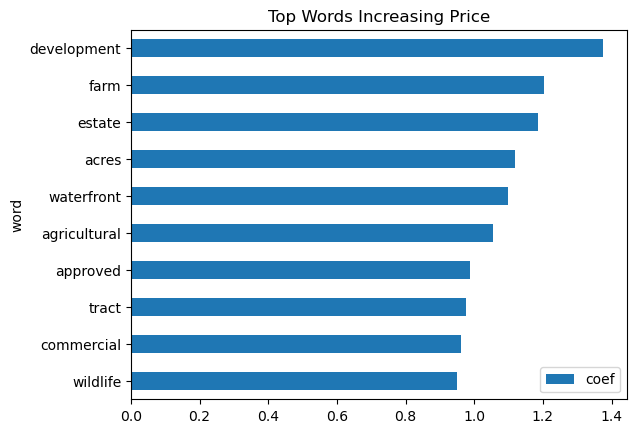

In [47]:
top_positive.head(10).plot(
    x="word", y="coef", kind="barh"
)
plt.title("Top Words Increasing Price")
plt.gca().invert_yaxis()
plt.show()

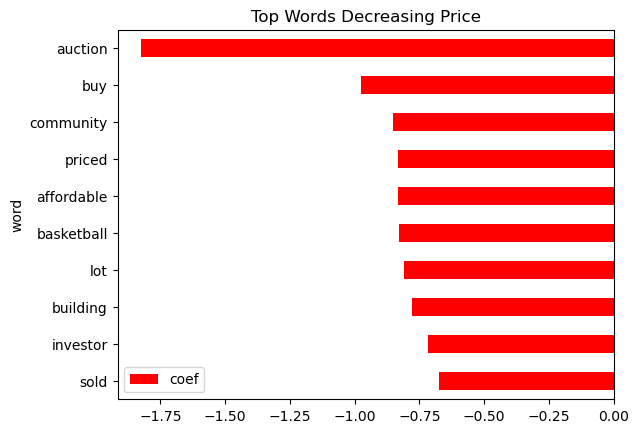

In [48]:
top_negative.head(10).plot(
    x="word", y="coef", kind="barh", color="red"
)
plt.title("Top Words Decreasing Price")
plt.gca().invert_yaxis()
plt.show()

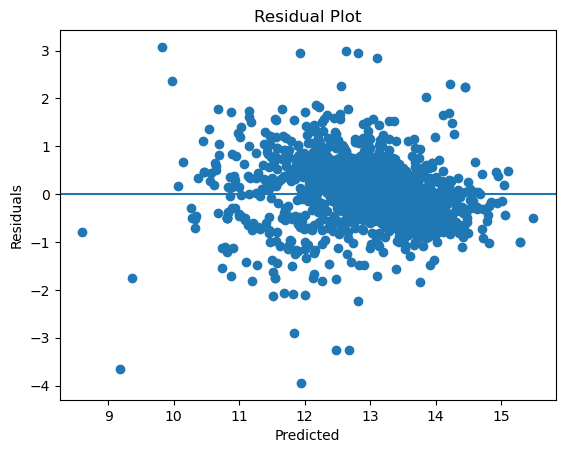

In [49]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train_transformed, y_train)

NameError: name 'X_train_transformed' is not defined

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

# columns
num_features = ['log_sqft', 'total_baths', 'home_age', 'days_on_mls', 'stories']
text_feature = 'text'

# preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('text', TfidfVectorizer(stop_words='english'), text_feature)
])

# pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('ridge', Ridge())
])

In [52]:
param_grid = {
    'ridge__alpha': [0.1, 1, 10, 50, 100],  # regularization strength
    'prep__text__max_features': [500, 1000, 3000],
    'prep__text__ngram_range': [(1,1), (1,2)]  # single words vs phrases
}

In [53]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid.fit(X, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWar

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['log_sqft',
                                                                          'total_baths',
                                                                          'home_age',
                                                                          'days_on_mls',
                                                                          'stories']),
                                                                        ('text',
                                                                         TfidfVectorizer(stop_words='english'),
                                                                         'text')])),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'prep__text__max_features': [500, 1000, 3000],
                         'prep__text__ngram_range': [(1, 1), (1, 2)],
                         'ridge__alpha': [0.1, 1, 10, 50, 100]},
             scoring='r2', verbose=2)

In [54]:
print("Best parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best parameters: {'prep__text__max_features': 3000, 'prep__text__ngram_range': (1, 1), 'ridge__alpha': 1}
Best CV R²: 0.658843142484778


In [55]:
best_model = grid.best_estimator_

from sklearn.metrics import r2_score, mean_squared_error

y_pred = best_model.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred, squared=False))

Test R²: 0.7805374998858559
Test RMSE: 0.43829032912057964


In [56]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))
print("Gap:", r2_score(y_train, train_pred) - r2_score(y_test, test_pred))

Train R2: 0.8135396255206704
Test R2: 0.7805374998858559
Gap: 0.03300212563481453


In [57]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

num_features = ['log_sqft', 'total_baths', 'home_age', 'days_on_mls', 'stories']

preprocessor_no_text = ColumnTransformer([
    ('num', StandardScaler(), num_features)
])

pipeline_no_text = Pipeline([
    ('prep', preprocessor_no_text),
    ('ridge', Ridge())
])

In [58]:
param_grid_no_text = {
    'ridge__alpha': [0.1, 1, 10, 50, 100]
}

from sklearn.model_selection import GridSearchCV

grid_no_text = GridSearchCV(
    pipeline_no_text,
    param_grid_no_text,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_no_text.fit(X, y)

/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWar

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['log_sqft',
                                                                          'total_baths',
                                                                          'home_age',
                                                                          'days_on_mls',
                                                                          'stories'])])),
                                       ('ridge', Ridge())]),
             n_jobs=-1, param_grid={'ridge__alpha': [0.1, 1, 10, 50, 100]},
             scoring='r2')

In [59]:
best_no_text = grid_no_text.best_estimator_

y_pred_no_text = best_no_text.predict(X_test)

from sklearn.metrics import r2_score

r2_no_text = r2_score(y_test, y_pred_no_text)

print("Baseline (no text) R²:", r2_no_text)

Baseline (no text) R²: 0.2943389634647454


In [61]:
r2_with_text = 0.7805  # from your output

In [62]:
improvement = r2_with_text - r2_no_text

print("R² with text:", r2_with_text)
print("R² without text:", r2_no_text)
print("Improvement from text:", improvement)

R² with text: 0.7805
R² without text: 0.2943389634647454
Improvement from text: 0.48616103653525455


In [63]:
df['text'].str.contains(r'\d{3,}', regex=True).sum()

5326

In [64]:
import re

def clean_text(text):
    text = re.sub(r'\$\d+', '', text)   # remove prices like $500000
    text = re.sub(r'\d+', '', text)     # remove numbers
    return text

df['text'] = df['text'].apply(clean_text)

In [65]:
train_pred = best_model.predict(X_train)
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))

Train R2: 0.8135396255206704
Test R2: 0.7805374998858559


In [67]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

In [68]:
df = pd.read_csv("virginia_housing_cleaned.csv")

df.shape
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9406 entries, 0 to 9405
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status            9406 non-null   object 
 1   text              9406 non-null   object 
 2   style             9406 non-null   object 
 3   zip_code          9406 non-null   int64  
 4   days_on_mls       9406 non-null   float64
 5   list_price        9406 non-null   float64
 6   list_date         9406 non-null   object 
 7   new_construction  9406 non-null   bool   
 8   county            9406 non-null   object 
 9   stories           9406 non-null   float64
 10  home_age          9406 non-null   float64
 11  total_baths       9406 non-null   float64
 12  desc_words        9406 non-null   int64  
 13  listing_month     9406 non-null   int64  
 14  log_price         9406 non-null   float64
 15  log_sqft          9406 non-null   float64
dtypes: bool(1), float64(7), int64(3), object(5

status              0
text                0
style               0
zip_code            0
days_on_mls         0
list_price          0
list_date           0
new_construction    0
county              0
stories             0
home_age            0
total_baths         0
desc_words          0
listing_month       0
log_price           0
log_sqft            0
dtype: int64

In [69]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\$\d+', '', text)   # remove prices like $500000
    text = re.sub(r'\d+', '', text)     # remove numbers
    text = re.sub(r'\s+', ' ', text)    # remove extra spaces
    return text.strip()

df["text_clean"] = df["text"].apply(clean_text)

In [70]:
premium_words = [
    "stainless steel",
    "granite countertops",
    "quartz countertops",
    "hardwood floors",
    "vaulted ceilings",
    "gourmet kitchen",
    "chef kitchen"
]

layout_words = [
    "open concept",
    "primary suite",
    "main level",
    "home office",
    "laundry room"
]

condition_words = [
    "brand new",
    "new construction",
    "fully renovated",
    "updated kitchen",
    "fresh paint"
]

outdoor_words = [
    "screened porch",
    "covered porch",
    "rear deck",
    "walking trails"
]

location_words = [
    "mountain views",
    "prime location",
    "conveniently located",
    "corner lot",
    "cul sac"
]

def phrase_count(text, phrase_list):
    return sum(phrase in text for phrase in phrase_list)

df["premium_score"] = df["text_clean"].apply(lambda x: phrase_count(x, premium_words))
df["layout_score"] = df["text_clean"].apply(lambda x: phrase_count(x, layout_words))
df["condition_score"] = df["text_clean"].apply(lambda x: phrase_count(x, condition_words))
df["outdoor_score"] = df["text_clean"].apply(lambda x: phrase_count(x, outdoor_words))
df["location_score"] = df["text_clean"].apply(lambda x: phrase_count(x, location_words))

In [71]:
num_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]

text_score_features = [
    "premium_score",
    "layout_score",
    "condition_score",
    "outdoor_score",
    "location_score"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

target = "log_price"

In [72]:
X_no_text = df[num_features + cat_features]
X_scores = df[num_features + text_score_features + cat_features]
X_tfidf = df[num_features + cat_features + ["text_clean"]]

y = df[target]

X_train_no_text, X_test_no_text, y_train, y_test = train_test_split(
    X_no_text, y, test_size=0.20, random_state=42
)

X_train_scores, X_test_scores, _, _ = train_test_split(
    X_scores, y, test_size=0.20, random_state=42
)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.20, random_state=42
)

In [73]:
preprocessor_no_text = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features)
    ]
)

model_no_text = Pipeline([
    ("prep", preprocessor_no_text),
    ("ridge", Ridge(alpha=1))
])

model_no_text.fit(X_train_no_text, y_train)

pred_no_text = model_no_text.predict(X_test_no_text)

r2_no_text = r2_score(y_test, pred_no_text)
rmse_no_text = np.sqrt(mean_squared_error(y_test, pred_no_text))
mae_no_text = mean_absolute_error(y_test, pred_no_text)

print("No Text Model")
print("R2:", r2_no_text)
print("RMSE:", rmse_no_text)
print("MAE:", mae_no_text)

No Text Model
R2: 0.5773270573456621
RMSE: 0.6082525671697612
MAE: 0.3362372535430938


In [74]:
preprocessor_scores = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features + text_score_features)
    ]
)

model_scores = Pipeline([
    ("prep", preprocessor_scores),
    ("ridge", Ridge(alpha=1))
])

model_scores.fit(X_train_scores, y_train)

pred_scores = model_scores.predict(X_test_scores)

r2_scores = r2_score(y_test, pred_scores)
rmse_scores = np.sqrt(mean_squared_error(y_test, pred_scores))
mae_scores = mean_absolute_error(y_test, pred_scores)

print("Text Score Model")
print("R2:", r2_scores)
print("RMSE:", rmse_scores)
print("MAE:", mae_scores)

Text Score Model
R2: 0.5778924692905153
RMSE: 0.6078455996034571
MAE: 0.33544190295557513


In [75]:
preprocessor_tfidf = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("text", TfidfVectorizer(
            stop_words="english",
            max_features=3000,
            ngram_range=(1, 1)
        ), "text_clean"),
        ("num", StandardScaler(), num_features)
    ]
)

model_tfidf = Pipeline([
    ("prep", preprocessor_tfidf),
    ("ridge", Ridge(alpha=1))
])

model_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = model_tfidf.predict(X_test_tfidf)

r2_tfidf = r2_score(y_test, pred_tfidf)
rmse_tfidf = np.sqrt(mean_squared_error(y_test, pred_tfidf))
mae_tfidf = mean_absolute_error(y_test, pred_tfidf)

print("TF-IDF + Ridge Model")
print("R2:", r2_tfidf)
print("RMSE:", rmse_tfidf)
print("MAE:", mae_tfidf)

TF-IDF + Ridge Model
R2: 0.7432498907159484
RMSE: 0.4740640750924696
MAE: 0.288850255180838


In [76]:
pipeline = Pipeline([
    ("prep", ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
            ("text", TfidfVectorizer(stop_words="english"), "text_clean"),
            ("num", StandardScaler(), num_features)
        ]
    )),
    ("ridge", Ridge())
])

param_grid = {
    "prep__text__max_features": [1000, 2000, 3000],
    "prep__text__ngram_range": [(1, 1), (1, 2)],
    "ridge__alpha": [0.1, 1, 2, 5, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_tfidf, y)

print("Best parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWar

Best parameters: {'prep__text__max_features': 3000, 'prep__text__ngram_range': (1, 1), 'ridge__alpha': 2}
Best CV R2: 0.7467555544833243


In [77]:
best_model = grid.best_estimator_

pred_best = best_model.predict(X_test_tfidf)

r2_best = r2_score(y_test, pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, pred_best))
mae_best = mean_absolute_error(y_test, pred_best)

print("Best Tuned Model")
print("R2:", r2_best)
print("RMSE:", rmse_best)
print("MAE:", mae_best)

Best Tuned Model
R2: 0.817293835430022
RMSE: 0.39990637491743575
MAE: 0.2387619173716131


In [78]:
train_pred = best_model.predict(X_train_tfidf)
test_pred = best_model.predict(X_test_tfidf)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Gap:", train_r2 - test_r2)

Train R2: 0.851260834702189
Test R2: 0.817293835430022
Gap: 0.033966999272167064


In [79]:
model_results = pd.DataFrame({
    "Model": [
        "No Text",
        "Text Scores",
        "TF-IDF + Ridge",
        "Tuned TF-IDF + Ridge"
    ],
    "R2": [
        r2_no_text,
        r2_scores,
        r2_tfidf,
        r2_best
    ],
    "RMSE": [
        rmse_no_text,
        rmse_scores,
        rmse_tfidf,
        rmse_best
    ],
    "MAE": [
        mae_no_text,
        mae_scores,
        mae_tfidf,
        mae_best
    ]
})

model_results

,Model,R2,RMSE,MAE
0,No Text,0.577327,0.608253,0.336237
1,Text Scores,0.577892,0.607846,0.335442
2,TF-IDF + Ridge,0.743250,0.474064,0.288850
3,Tuned TF-IDF + Ridge,0.817294,0.399906,0.238762


In [80]:
improvement = r2_best - r2_no_text

print("R2 without text:", r2_no_text)
print("R2 with text:", r2_best)
print("Improvement from text:", improvement)

R2 without text: 0.5773270573456621
R2 with text: 0.817293835430022
Improvement from text: 0.23996677808435984


In [81]:
train_r2 - test_r2

0.033966999272167064

[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=1; total time=   3.5s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=2; total time=   3.2s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=10; total time=   3.0s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=0.1; total time=   7.9s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=2; total time=   7.9s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=10; total time=   7.6s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=0.1; total time=   4.1s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=2; total time=   3.6s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=10; total time=   3.3s
[CV] END prep__text__max_featu

[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=1; total time=   3.3s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=1; total time=   3.0s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=5; total time=   2.9s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=10; total time=   2.9s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=1; total time=   7.5s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=5; total time=   7.6s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=10; total time=   7.5s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=1; total time=   3.8s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=2; total time=   3.4s
[CV] END prep__text__max_features=2

In [82]:
# create keyword flag
df["luxury_flag"] = df["text"].str.contains("luxury", case=False, na=False).astype(int)

import statsmodels.api as sm

X = df[["luxury_flag", "log_sqft", "total_baths", "home_age"]]
X = sm.add_constant(X)
y = df["log_price"]

model_keyword = sm.OLS(y, X).fit()
print(model_keyword.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     1190.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        16:47:59   Log-Likelihood:                -10324.
No. Observations:                9406   AIC:                         2.066e+04
Df Residuals:                    9401   BIC:                         2.069e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           9.8122      0.176     55.839      

In [83]:
from scipy.stats import ttest_ind

luxury_prices = df[df["luxury_flag"] == 1]["log_price"]
non_luxury_prices = df[df["luxury_flag"] == 0]["log_price"]

t_stat, p_val = ttest_ind(luxury_prices, non_luxury_prices, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_val)

t-stat: 22.756151276514025
p-value: 4.2242992837294226e-102


In [84]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_features = ["log_sqft", "total_baths", "home_age"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("text", TfidfVectorizer(max_features=3000, stop_words="english"), "text")
])

model = Pipeline([
    ("prep", preprocessor),
    ("ridge", Ridge(alpha=1))
])

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['log_sqft', 'total_baths',
                                                   'home_age']),
                                                 ('text',
                                                  TfidfVectorizer(max_features=3000,
                                                                  stop_words='english'),
                                                  'text')])),
                ('ridge', Ridge(alpha=1))])

In [85]:
tfidf = model.named_steps["prep"].named_transformers_["text"]
feature_names = tfidf.get_feature_names_out()

coefs = model.named_steps["ridge"].coef_

text_coefs = coefs[-len(feature_names):]

import pandas as pd
word_df = pd.DataFrame({
    "word": feature_names,
    "coef": text_coefs
})

top_positive = word_df.sort_values("coef", ascending=False).head(15)
top_negative = word_df.sort_values("coef").head(15)

print(top_positive)
print(top_negative)

            word      coef
977       estate  1.391137
1705      mclean  1.263524
1042        farm  1.194412
2904  washington  1.161630
1035       falls  1.073450
1730       metro  1.050681
2148     rambler  1.044547
227     approved  1.025478
239    arlington  1.016168
399     braddock  1.011865
623     compound  0.993988
2229  residences  0.942853
1032     fairfax  0.927446
1565      legacy  0.921917
886     easement  0.914295
            word      coef
266      auction -2.539245
1629         lot -1.893330
428     building -1.602438
424        build -1.520783
1286     harbour -1.411368
2916     website -1.411002
425    buildable -1.328220
2865     virtual -1.219670
1571      letter -1.215745
167   affordable -1.196747
309   basketball -1.185088
457         camp -1.177028
252     assessed -1.157343
819    diligence -1.112114
2356      septic -1.108561


In [86]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/yarayaghi/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [87]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

sentences = df["text"].dropna().apply(lambda x: word_tokenize(x.lower()))

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=5)

# example
print(w2v_model.wv.most_similar("luxury"))

[('refined', 0.6368322968482971), ('elegance', 0.6193338632583618), ('craftsmanship', 0.5975015163421631), ('plank', 0.5837392210960388), ('contemporary', 0.5627313852310181), ('meets', 0.5602663159370422), ('style', 0.5564631223678589), ('low-maintenance', 0.550222635269165), ('sophistication', 0.5322836637496948), ('vinyl', 0.5283541083335876)]


In [88]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("prep", preprocessor),
    ("lasso", Lasso(alpha=0.01))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

from sklearn.metrics import r2_score
print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso R2: 0.3003600380499529


In [89]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.6307641296137183


In [90]:
from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline([
    ("prep", preprocessor),
    ("dt", DecisionTreeRegressor(max_depth=5))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("DT R2:", r2_score(y_test, y_pred_dt))

DT R2: 0.5038508163780614


In [91]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

results = []

results.append(evaluate("Ridge (TF-IDF)", y_test, y_pred))
results.append(evaluate("Lasso", y_test, y_pred_lasso))
results.append(evaluate("Random Forest", y_test, y_pred_rf))
results.append(evaluate("Decision Tree", y_test, y_pred_dt))

results_df = pd.DataFrame(results)
print(results_df)

            Model        R2      RMSE       MAE
0  Ridge (TF-IDF)  0.780537  0.438290  0.288608
1           Lasso  0.300360  0.782562  0.488887
2   Random Forest  0.630764  0.568504  0.345484
3   Decision Tree  0.503851  0.659004  0.407548


In [92]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Features for regression
reg_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories",
    "premium_score",
    "layout_score",
    "condition_score",
    "outdoor_score",
    "location_score"
]

X_reg = df[reg_features]
X_reg = sm.add_constant(X_reg)

y_reg = df["log_price"]

ols_model = sm.OLS(y_reg, X_reg).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     572.1
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        21:55:05   Log-Likelihood:                -10013.
No. Observations:                9406   AIC:                         2.005e+04
Df Residuals:                    9395   BIC:                         2.013e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.7565      0.172     

In [93]:
coef_table = pd.DataFrame({
    "Feature": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "P_value": ols_model.pvalues.values,
    "Lower_CI": ols_model.conf_int()[0].values,
    "Upper_CI": ols_model.conf_int()[1].values
})

coef_table = coef_table[coef_table["Feature"] != "const"]

coef_table["Significant"] = coef_table["P_value"] < 0.05

coef_table.sort_values("Coefficient", ascending=False)

,Feature,Coefficient,P_value,Lower_CI,Upper_CI,Significant
2,total_baths,0.361846,3.217399e-176,0.337317,0.386374,True
1,log_sqft,0.274252,6.826080e-27,0.224338,0.324167,True
8,condition_score,0.123463,1.510335e-17,0.095134,0.151791,True
7,layout_score,0.118240,5.949291e-48,0.102399,0.134081,True
6,premium_score,0.117790,2.483207e-41,0.100727,0.134854,True
9,outdoor_score,0.086321,1.090033e-05,0.047873,0.124770,True
3,home_age,0.001940,1.041772e-14,0.001449,0.002431,True
4,days_on_mls,-0.001284,1.293821e-01,-0.002943,0.000375,False
10,location_score,-0.040535,1.138788e-02,-0.071928,-0.009142,True
5,stories,-0.044418,2.357018e-04,-0.068086,-0.020750,True


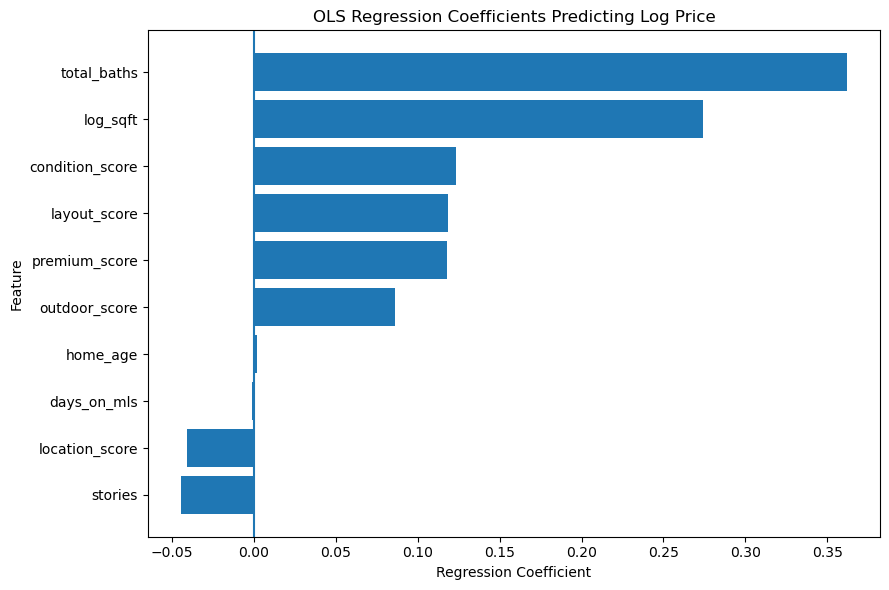

In [94]:
import matplotlib.pyplot as plt

plot_df = coef_table.sort_values("Coefficient")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["Feature"], plot_df["Coefficient"])

plt.axvline(0)
plt.xlabel("Regression Coefficient")
plt.ylabel("Feature")
plt.title("OLS Regression Coefficients Predicting Log Price")

plt.tight_layout()
plt.show()

In [95]:
df['text'].str.contains(r'\d').sum()

8373

In [96]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\$\s*\d[\d,]*', '', text)  # remove prices
    text = re.sub(r'\d+', '', text)            # remove all numbers
    text = re.sub(r'\s+', ' ', text)           # remove extra spaces
    return text.strip()

df["text_clean"] = df["text"].apply(clean_text)

# check digits after cleaning
print(df["text_clean"].str.contains(r'\d', regex=True).sum())

0


In [97]:
num_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

X = df[num_features + cat_features + ["text_clean"]]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

pipeline = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features),
        ("text", TfidfVectorizer(stop_words="english"), "text_clean")
    ])),
    ("ridge", Ridge())
])

param_grid = {
    "prep__text__max_features": [1000, 2000, 3000],
    "prep__text__ngram_range": [(1, 1), (1, 2)],
    "ridge__alpha": [0.1, 1, 2, 5, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yarayaghi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWar

Best parameters: {'prep__text__max_features': 3000, 'prep__text__ngram_range': (1, 1), 'ridge__alpha': 2}
Best CV R2: 0.7788659374121591


In [98]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Gap:", train_r2 - test_r2)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

Train R2: 0.8531699367503186
Test R2: 0.7371223195527208
Gap: 0.11604761719759782
Train RMSE: 0.3364935109379767
Test RMSE: 0.4796877014463836
Train MAE: 0.21373435499330867
Test MAE: 0.2841506180284467


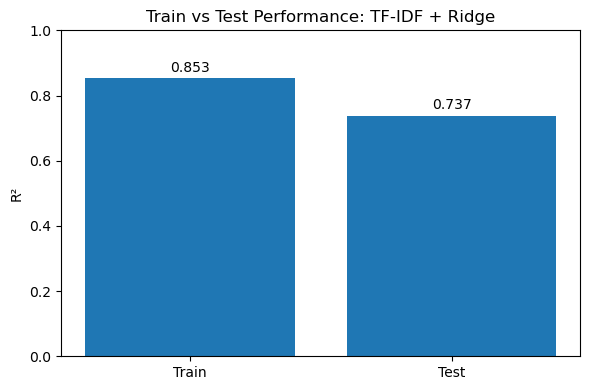

In [99]:
perf_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "R2": [train_r2, test_r2]
})

plt.figure(figsize=(6, 4))
plt.bar(perf_df["Dataset"], perf_df["R2"])
plt.ylabel("R²")
plt.title("Train vs Test Performance: TF-IDF + Ridge")
plt.ylim(0, 1)

for i, value in enumerate(perf_df["R2"]):
    plt.text(i, value + 0.02, round(value, 3), ha="center")

plt.tight_layout()
plt.show()

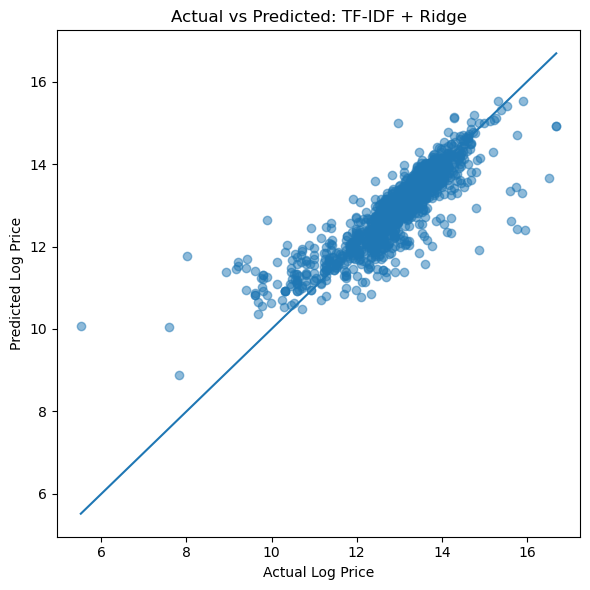

[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=1; total time=   2.5s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=2; total time=   2.7s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=5; total time=   2.5s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=0.1; total time=   6.1s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=2; total time=   6.0s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=5; total time=   5.7s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=10; total time=   5.9s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=2; total time=   2.6s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=10; total time=   2.5s
[CV] END prep__text__max_features

[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=0.1; total time=   2.6s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=5; total time=   2.8s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 1), ridge__alpha=10; total time=   2.6s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=1; total time=   5.9s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=2; total time=   6.2s
[CV] END prep__text__max_features=1000, prep__text__ngram_range=(1, 2), ridge__alpha=10; total time=   5.9s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=0.1; total time=   3.1s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=2; total time=   2.8s
[CV] END prep__text__max_features=2000, prep__text__ngram_range=(1, 1), ridge__alpha=5; total time=   2.6s
[CV] END prep__text__max_featur

In [100]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.5)

min_val = min(y_test.min(), test_pred.min())
max_val = max(y_test.max(), test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted: TF-IDF + Ridge")

plt.tight_layout()
plt.show()

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# features
num_features = ["log_sqft", "total_baths", "home_age", "days_on_mls", "stories"]
cat_features = ["county", "style", "status", "new_construction"]

# -------------------------
# Same train/test split
# -------------------------
X = df[num_features + cat_features + ["text_clean"]]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# -------------------------
# Model 1: NO TEXT
# -------------------------
no_text_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), num_features)
])

no_text_model = Pipeline([
    ("prep", no_text_preprocessor),
    ("ridge", Ridge(alpha=2))
])

no_text_model.fit(X_train[num_features + cat_features], y_train)
pred_no_text = no_text_model.predict(X_test[num_features + cat_features])

# -------------------------
# Model 2: WITH TEXT
# -------------------------
text_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), num_features),
    ("text", TfidfVectorizer(
        stop_words="english",
        max_features=3000,
        ngram_range=(1, 1)
    ), "text_clean")
])

text_model = Pipeline([
    ("prep", text_preprocessor),
    ("ridge", Ridge(alpha=2))
])

text_model.fit(X_train, y_train)
pred_text = text_model.predict(X_test)

# -------------------------
# Compare results
# -------------------------
comparison = pd.DataFrame({
    "Model": ["No Text", "With Text"],
    "R2": [
        r2_score(y_test, pred_no_text),
        r2_score(y_test, pred_text)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_no_text)),
        np.sqrt(mean_squared_error(y_test, pred_text))
    ],
    "MAE": [
        mean_absolute_error(y_test, pred_no_text),
        mean_absolute_error(y_test, pred_text)
    ]
})

comparison["R2_Improvement"] = comparison["R2"] - comparison.loc[0, "R2"]

comparison

,Model,R2,RMSE,MAE,R2_Improvement
0,No Text,0.576948,0.608526,0.336181,0.000000
1,With Text,0.737122,0.479688,0.284151,0.160175


In [102]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Features
num_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

X = df[num_features + cat_features]
y = df["log_price"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Preprocessing
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), num_features)
])

# Decision Tree pipeline
dt_model = Pipeline([
    ("prep", preprocessor),
    ("tree", DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=50,
        random_state=42
    ))
])

# Fit model
dt_model.fit(X_train, y_train)

# Predictions
train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_mae = mean_absolute_error(y_test, test_pred)

print("Decision Tree Results")
print("Train R2:", round(train_r2, 3))
print("Test R2:", round(test_r2, 3))
print("Gap:", round(train_r2 - test_r2, 3))
print("Test RMSE:", round(test_rmse, 3))
print("Test MAE:", round(test_mae, 3))

Decision Tree Results
Train R2: 0.563
Test R2: 0.466
Gap: 0.097
Test RMSE: 0.684
Test MAE: 0.416


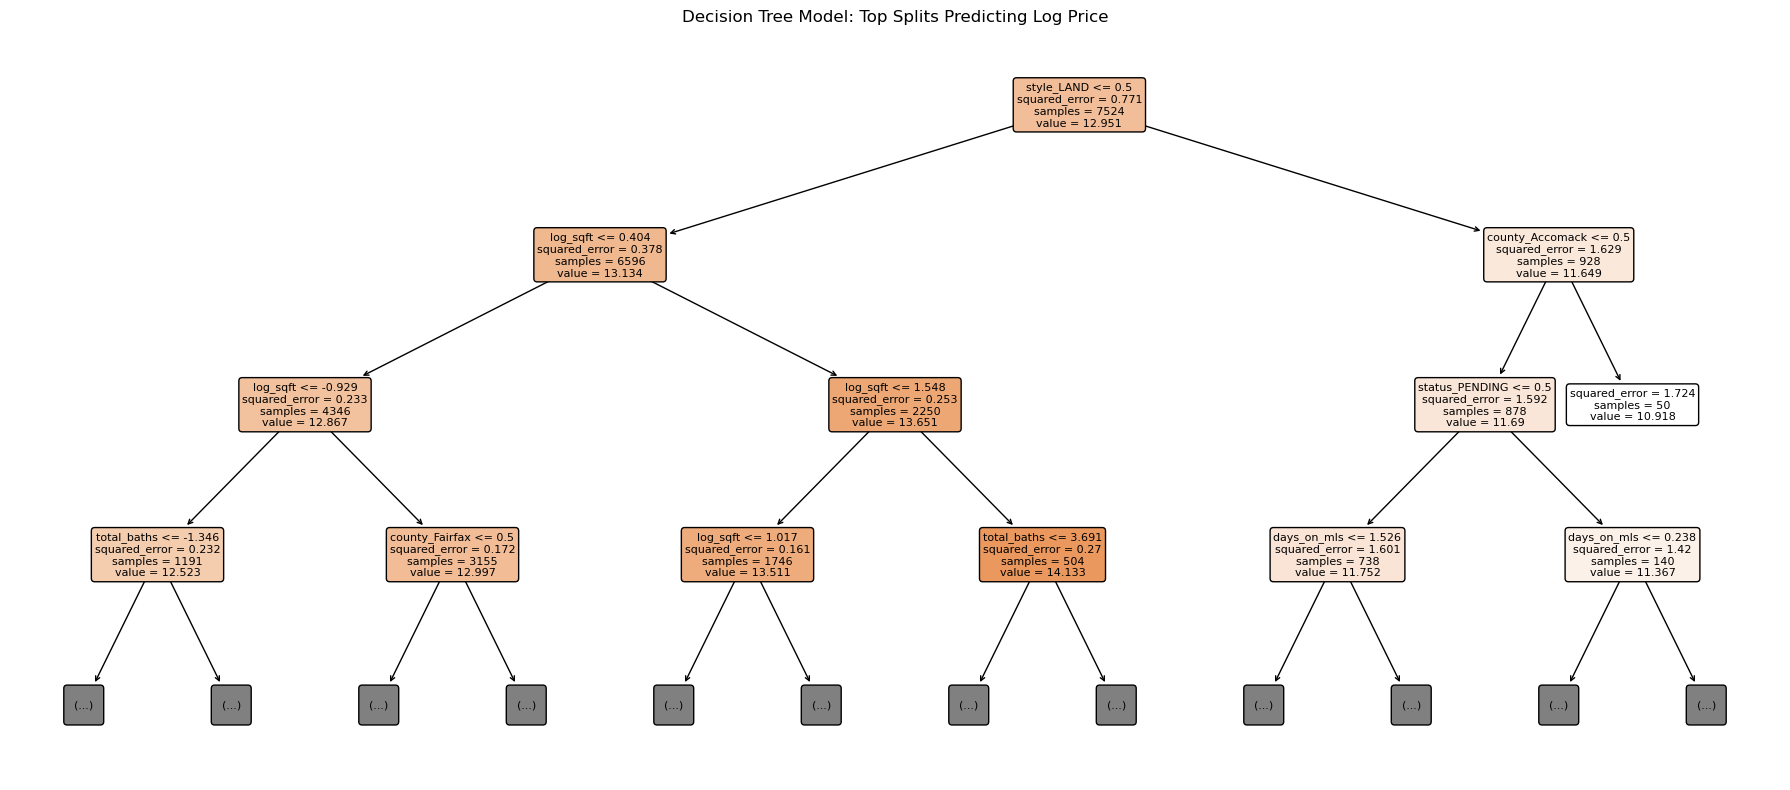

In [108]:
# Get transformed feature names
cat_names = dt_model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features)
feature_names = list(cat_names) + num_features

# Plot tree
plt.figure(figsize=(18, 8))

plot_tree(
    dt_model.named_steps["tree"],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Model: Top Splits Predicting Log Price")
plt.tight_layout()
plt.show()

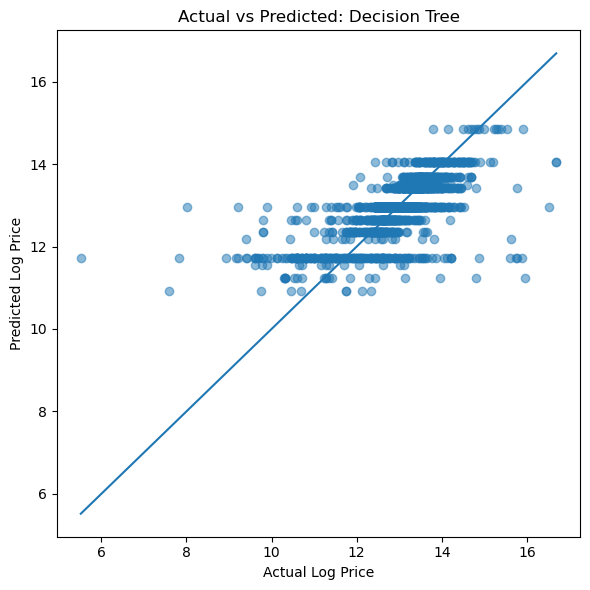

In [104]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.5)

min_val = min(y_test.min(), test_pred.min())
max_val = max(y_test.max(), test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted: Decision Tree")

plt.tight_layout()
plt.show()

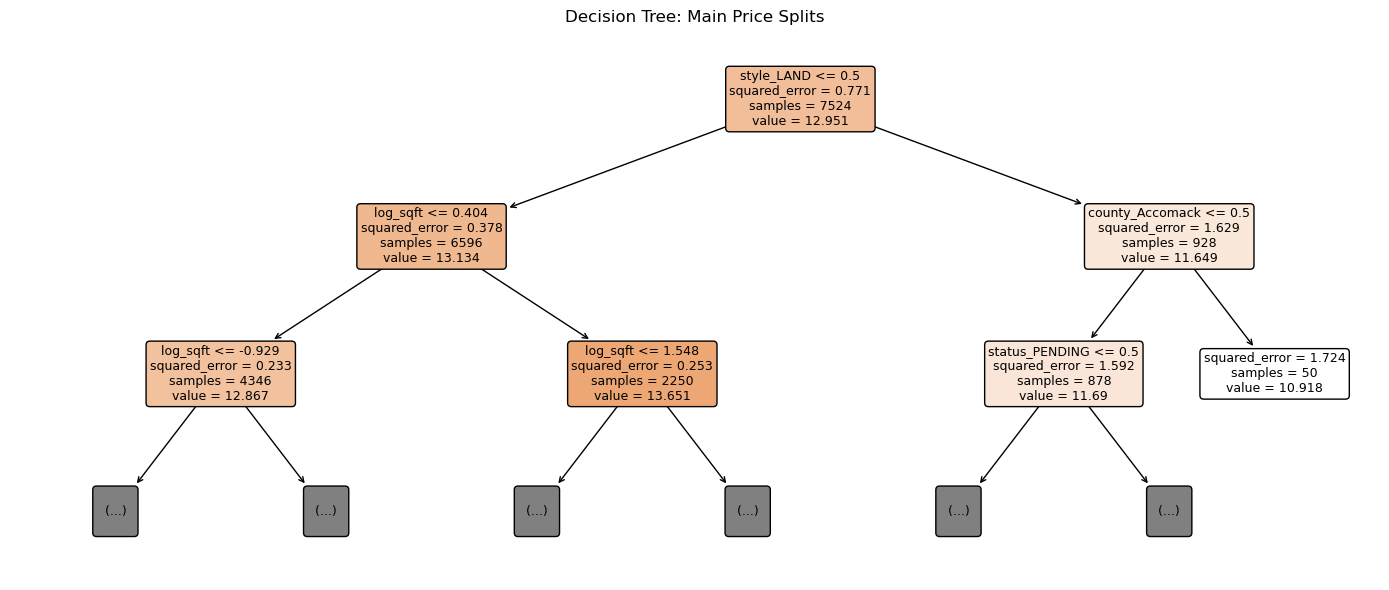

In [110]:
plt.figure(figsize=(14, 6))

plot_tree(
    dt_model.named_steps["tree"],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=9
)

plt.title("Decision Tree: Main Price Splits")
plt.tight_layout()
plt.show()

In [111]:
print("No text R2:", r2_no_text)
print("With text R2:", r2_with_text)

No text R2: 0.5773270573456621
With text R2: 0.7805


In [113]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [114]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\$\s*\d[\d,]*', '', text)  # remove prices
    text = re.sub(r'\d+', '', text)            # remove numbers
    text = re.sub(r'\s+', ' ', text)           # remove extra spaces
    return text.strip()

df["text_clean"] = df["text"].apply(clean_text)

# check that numbers were removed
print(df["text_clean"].str.contains(r'\d', regex=True).sum())

0


In [115]:
df["desc_words"] = df["text_clean"].str.split().apply(len)

keywords = [
    "luxury",
    "modern",
    "renovated",
    "waterfront",
    "estate",
    "auction",
    "investor",
    "affordable"
]

for word in keywords:
    df[f"has_{word}"] = df["text_clean"].str.contains(word, case=False, na=False).astype(int)

In [116]:
structural_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]

text_features = [
    "desc_words",
    "has_luxury",
    "has_modern",
    "has_renovated",
    "has_waterfront",
    "has_estate",
    "has_auction",
    "has_investor",
    "has_affordable"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

y = df["log_price"]

In [117]:
X_no_text = df[structural_features + cat_features]
X_with_text = df[structural_features + text_features + cat_features]

X_train_no_text, X_test_no_text, y_train, y_test = train_test_split(
    X_no_text, y, test_size=0.20, random_state=42
)

X_train_text, X_test_text, _, _ = train_test_split(
    X_with_text, y, test_size=0.20, random_state=42
)

In [118]:
preprocessor_no_text = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), structural_features)
])

tree_no_text = Pipeline([
    ("prep", preprocessor_no_text),
    ("tree", DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=50,
        random_state=42
    ))
])

tree_no_text.fit(X_train_no_text, y_train)

pred_no_text = tree_no_text.predict(X_test_no_text)

r2_no_text = r2_score(y_test, pred_no_text)
rmse_no_text = np.sqrt(mean_squared_error(y_test, pred_no_text))
mae_no_text = mean_absolute_error(y_test, pred_no_text)

print("Decision Tree WITHOUT Text")
print("R2:", round(r2_no_text, 3))
print("RMSE:", round(rmse_no_text, 3))
print("MAE:", round(mae_no_text, 3))

Decision Tree WITHOUT Text
R2: 0.466
RMSE: 0.684
MAE: 0.416


In [119]:
all_num_features = structural_features + text_features

preprocessor_text = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), all_num_features)
])

tree_with_text = Pipeline([
    ("prep", preprocessor_text),
    ("tree", DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=50,
        random_state=42
    ))
])

tree_with_text.fit(X_train_text, y_train)

pred_text = tree_with_text.predict(X_test_text)

r2_text = r2_score(y_test, pred_text)
rmse_text = np.sqrt(mean_squared_error(y_test, pred_text))
mae_text = mean_absolute_error(y_test, pred_text)

print("Decision Tree WITH Text")
print("R2:", round(r2_text, 3))
print("RMSE:", round(rmse_text, 3))
print("MAE:", round(mae_text, 3))

print("R2 Improvement from Text:", round(r2_text - r2_no_text, 3))

Decision Tree WITH Text
R2: 0.503
RMSE: 0.66
MAE: 0.404
R2 Improvement from Text: 0.037


In [120]:
tree_results = pd.DataFrame({
    "Model": ["Decision Tree: No Text", "Decision Tree: With Text"],
    "R2": [r2_no_text, r2_text],
    "RMSE": [rmse_no_text, rmse_text],
    "MAE": [mae_no_text, mae_text]
})

tree_results["R2_Improvement"] = tree_results["R2"] - tree_results.loc[0, "R2"]

tree_results

,Model,R2,RMSE,MAE,R2_Improvement
0,Decision Tree: No Text,0.465753,0.683838,0.415984,0.000000
1,Decision Tree: With Text,0.502577,0.659849,0.403828,0.036824


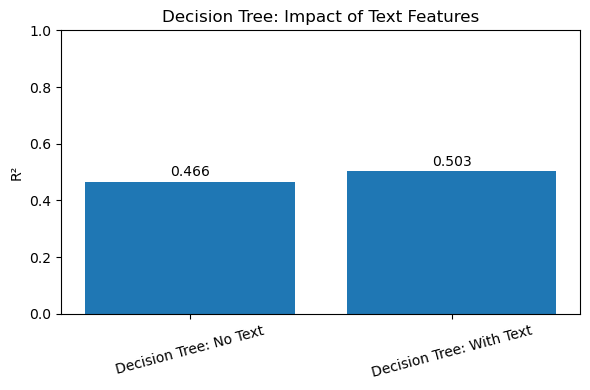

In [121]:
plt.figure(figsize=(6, 4))

plt.bar(tree_results["Model"], tree_results["R2"])

plt.ylabel("R²")
plt.title("Decision Tree: Impact of Text Features")
plt.ylim(0, 1)
plt.xticks(rotation=15)

for i, value in enumerate(tree_results["R2"]):
    plt.text(i, value + 0.02, round(value, 3), ha="center")

plt.tight_layout()
plt.show()

In [122]:
# Get feature names after preprocessing
cat_names = tree_with_text.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features)
feature_names = list(cat_names) + all_num_features

importances = tree_with_text.named_steps["tree"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feat_imp = feat_imp.sort_values("Importance", ascending=False)

feat_imp.head(15)

,Feature,Importance
88,style_LAND,0.531304
98,log_sqft,0.380672
103,desc_words,0.049559
22,county_Fairfax,0.020165
99,total_baths,0.009784
94,status_FOR_SALE,0.006510
101,days_on_mls,0.002006
0,county_Accomack,0.000000
72,county_Rockbridge,0.000000
73,county_Rockingham,0.000000


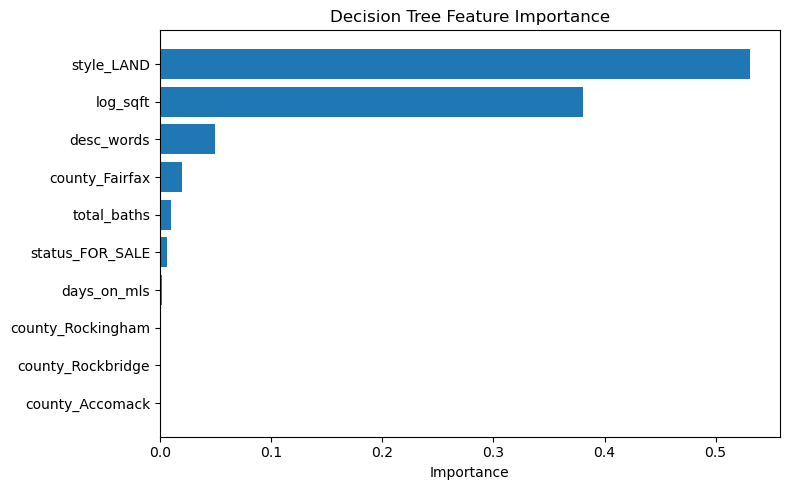

In [123]:
top_imp = feat_imp.head(10).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_imp["Feature"], top_imp["Importance"])

plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")

plt.tight_layout()
plt.show()

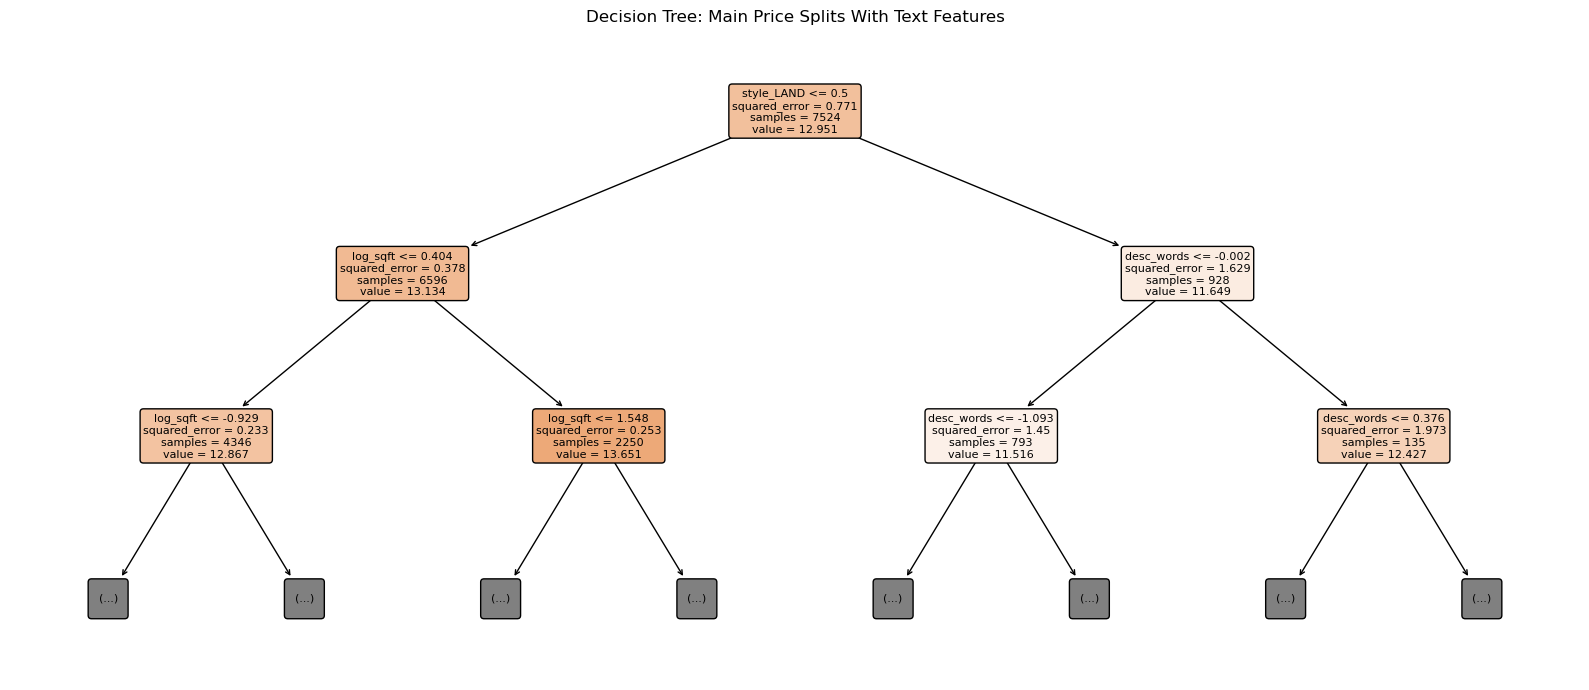

In [124]:
plt.figure(figsize=(16, 7))

plot_tree(
    tree_with_text.named_steps["tree"],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=8
)

plt.title("Decision Tree: Main Price Splits With Text Features")
plt.tight_layout()
plt.show()

In [125]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

# Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\$\s*\d[\d,]*', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["text_clean"] = df["text"].apply(clean_text)

num_features = [
    "log_sqft",
    "total_baths",
    "home_age",
    "days_on_mls",
    "stories"
]

cat_features = [
    "county",
    "style",
    "status",
    "new_construction"
]

X = df[num_features + cat_features + ["text_clean"]]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

text_model = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features),
        ("text", TfidfVectorizer(
            stop_words="english",
            max_features=3000,
            ngram_range=(1, 1)
        ), "text_clean")
    ])),
    ("ridge", Ridge(alpha=2))
])

text_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['county', 'style', 'status',
                                                   'new_construction']),
                                                 ('num', StandardScaler(),
                                                  ['log_sqft', 'total_baths',
                                                   'home_age', 'days_on_mls',
                                                   'stories']),
                                                 ('text',
                                                  TfidfVectorizer(max_features=3000,
                                                                  stop_words='english'),
                                                  'text_clean')])),
                ('ridge', Ridge(alpha=2))])

In [126]:
# Get TF-IDF feature names
feature_names = text_model.named_steps["prep"].named_transformers_["text"].get_feature_names_out()

# Get Ridge coefficients
coefs = text_model.named_steps["ridge"].coef_

# Get names before text features
cat_names = text_model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features)
num_names = num_features

start = len(cat_names) + len(num_names)
end = start + len(feature_names)

text_coefs = pd.DataFrame({
    "word": feature_names,
    "coef": coefs[start:end]
})

top_positive = text_coefs.sort_values("coef", ascending=False).head(15)
top_negative = text_coefs.sort_values("coef", ascending=True).head(15)

print("Words associated with higher prices:")
print(top_positive)

print("\nWords associated with lower prices:")
print(top_negative)

Words associated with higher prices:
              word      coef
729    development  1.116547
24           acres  1.080095
894         estate  1.067696
2903    waterfront  1.035553
963           farm  1.031861
60    agricultural  1.001688
2933      wildlife  0.958374
2410         sites  0.928857
507     commercial  0.918174
528       compound  0.898394
2714         tract  0.873092
116       approved  0.872906
1508        legacy  0.856015
802       easement  0.851044
1094      frontage  0.830665

Words associated with lower prices:
            word      coef
155      auction -1.671300
2457        sold -0.886192
330     building -0.849547
1222     harbour -0.808088
511    community -0.803567
141     assessed -0.770974
200   basketball -0.765124
2911     website -0.762158
2856     virtual -0.748522
53    affordable -0.740622
2040      priced -0.731903
346          buy -0.730147
244          bid -0.729980
1409    investor -0.701960
1574         lot -0.683469


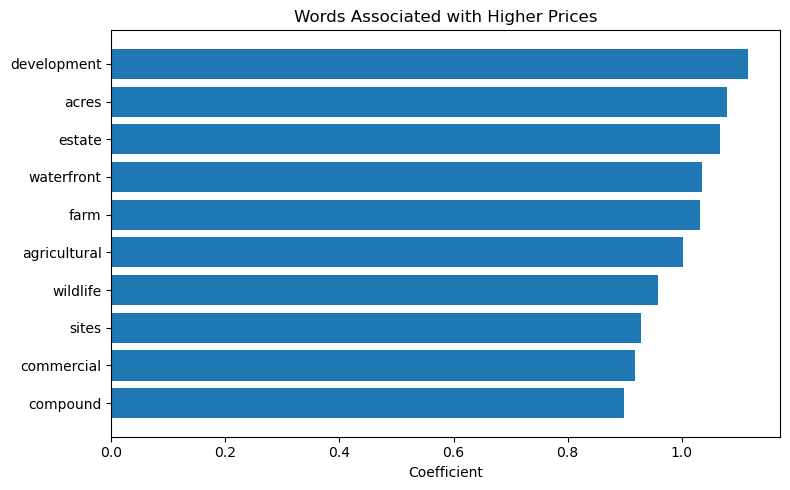

In [127]:
top_pos_plot = top_positive.head(10).sort_values("coef")

plt.figure(figsize=(8, 5))
plt.barh(top_pos_plot["word"], top_pos_plot["coef"])
plt.xlabel("Coefficient")
plt.title("Words Associated with Higher Prices")
plt.tight_layout()
plt.show()

TypeError: 'Axes' object is not subscriptable

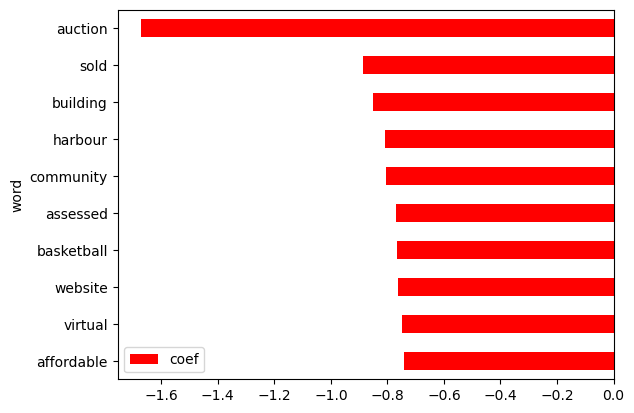

<Figure size 800x500 with 0 Axes>

In [134]:
top_neg_plot = top_negative.head(10).sort_values("coef", ascending=False).plot(
    x="word", kind="barh", color="red"
)

plt.figure(figsize=(8, 5))
plt.barh(top_neg_plot["word"], top_neg_plot["coef"])
plt.xlabel("Coefficient")
plt.title("Words Associated with Lower Prices")
plt.tight_layout()
plt.show()

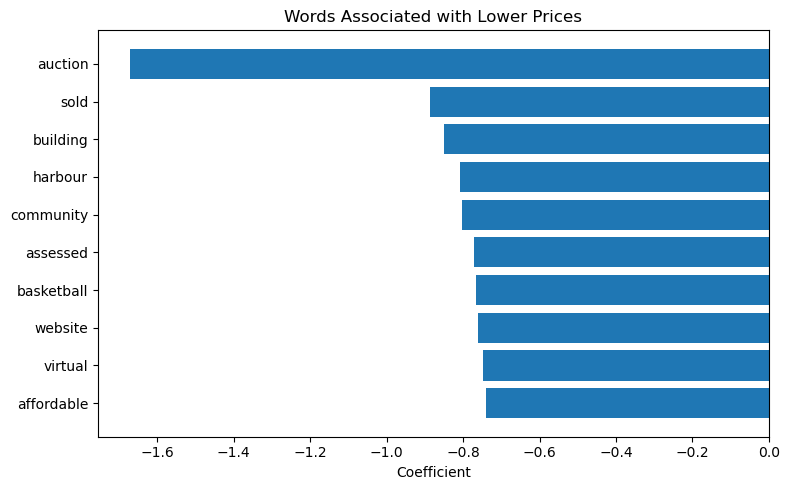

In [133]:
top_neg_plot = top_negative.head(10).sort_values("coef", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(top_neg_plot["word"], top_neg_plot["coef"])
plt.xlabel("Coefficient")
plt.title("Words Associated with Lower Prices")
plt.tight_layout()
plt.show()